# winequality-red

In [1]:
#загрузка библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

In [2]:
#загрузка датасета
red_pd = pd.read_csv('/content/winequality-red.csv', sep = ";")

In [3]:
red_pd.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
red_pd.tail(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [5]:
red_pd.shape
#1599 наблюдений, 11 независимых переменных, 1 целевая переменная quality

(1599, 12)

In [6]:
red_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
column_red = red_pd.columns
column_red

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [8]:
#вывод основной статистики
red_pd.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


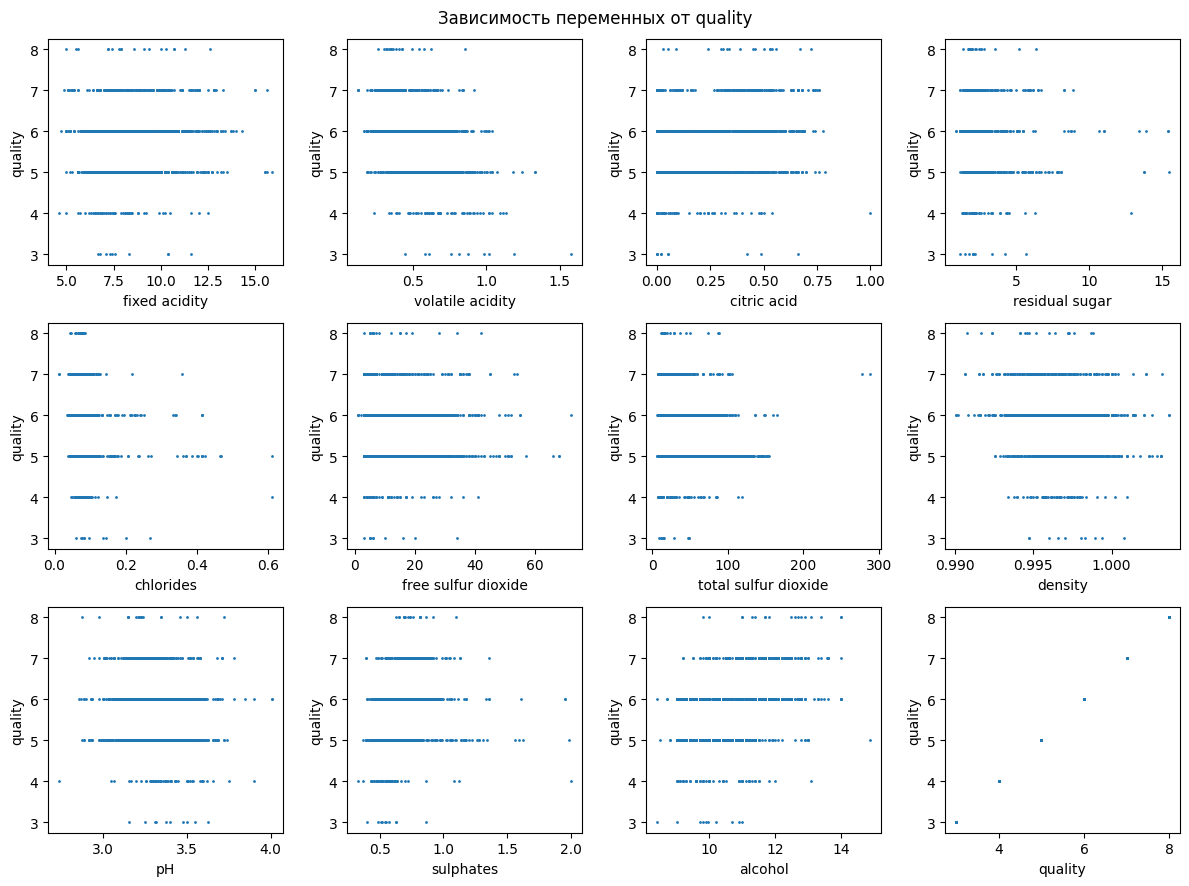

In [9]:
#зависимость переменных от таргета
fig, axs = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Зависимость переменных от quality')
for i, column in enumerate(column_red):
    row = i // 4  # вычисляем строку
    col = i % 4   # вычисляем столбец
    n = col + row * 4
    feature = column_red[n]
    axs[row, col].scatter(red_pd.iloc[:,n], red_pd.quality, s=1)
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('quality')
plt.tight_layout()
plt.show()

In [10]:
y = red_pd.quality
X = red_pd.drop(['quality'], axis=1)

In [11]:
#независимые переменные
X.shape

(1599, 11)

In [12]:
#целевая переменная
y.shape

(1599,)

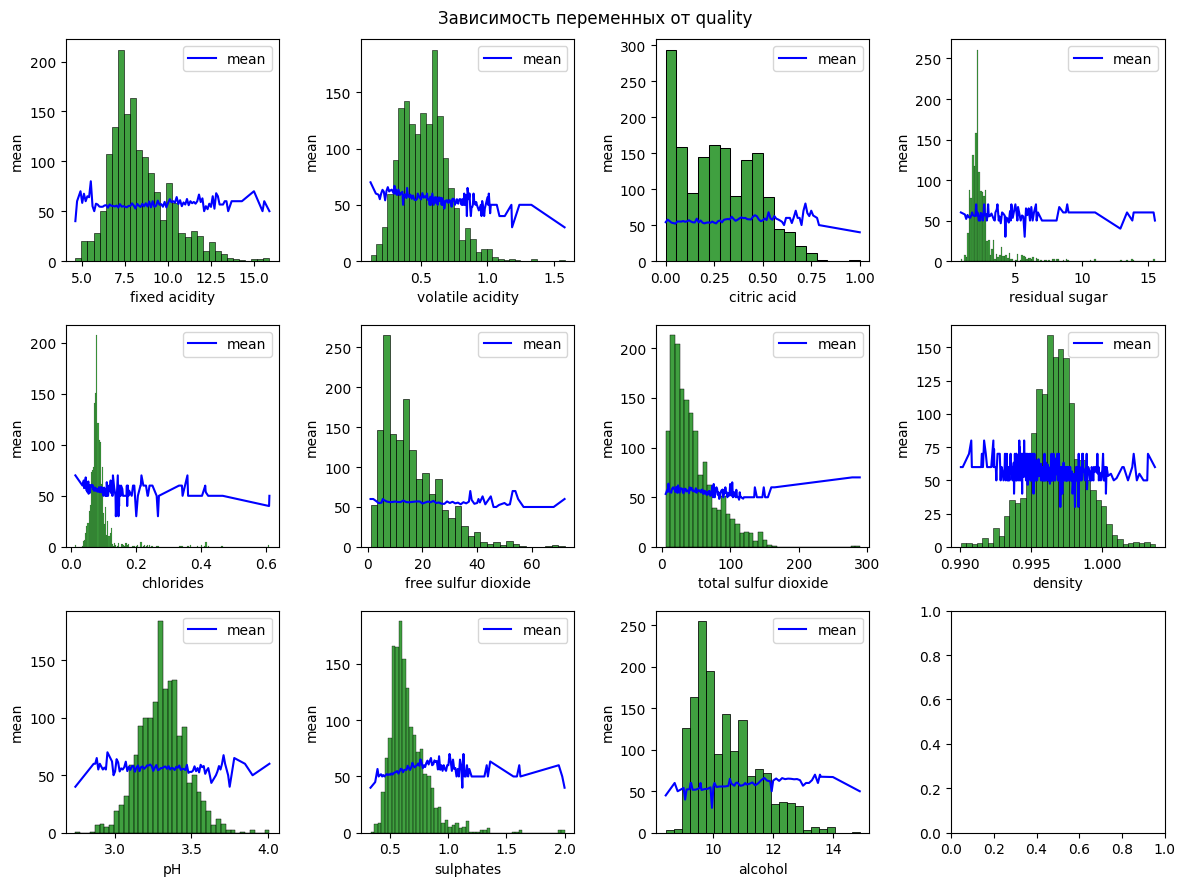

In [13]:
#зависимость переменных от таргета
fig, axs = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Зависимость переменных от quality')
for i, column in enumerate(X.columns):
    row = i // 4  # вычисляем строку
    col = i % 4   # вычисляем столбец
    piv=red_pd.pivot_table(index=column,values='quality',aggfunc={'quality': ['count', 'mean']},dropna=False)
    piv['mean']=piv['mean']*10
    piv.sort_values('mean', ascending=True, inplace=True)
    piv.insert(1,'percent',piv['count']/len(red_pd)*100)
    sns.lineplot(data=piv,x=column,y="mean",color='blue',label='mean',ax=axs[row, col])
    sns.histplot(data=red_pd,x=column,color='green',label='count',ax=axs[row, col])
plt.tight_layout()
plt.show()
plt.close()

In [14]:
#корреляционная матрица
correlation_matrix = red_pd.corr()
correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


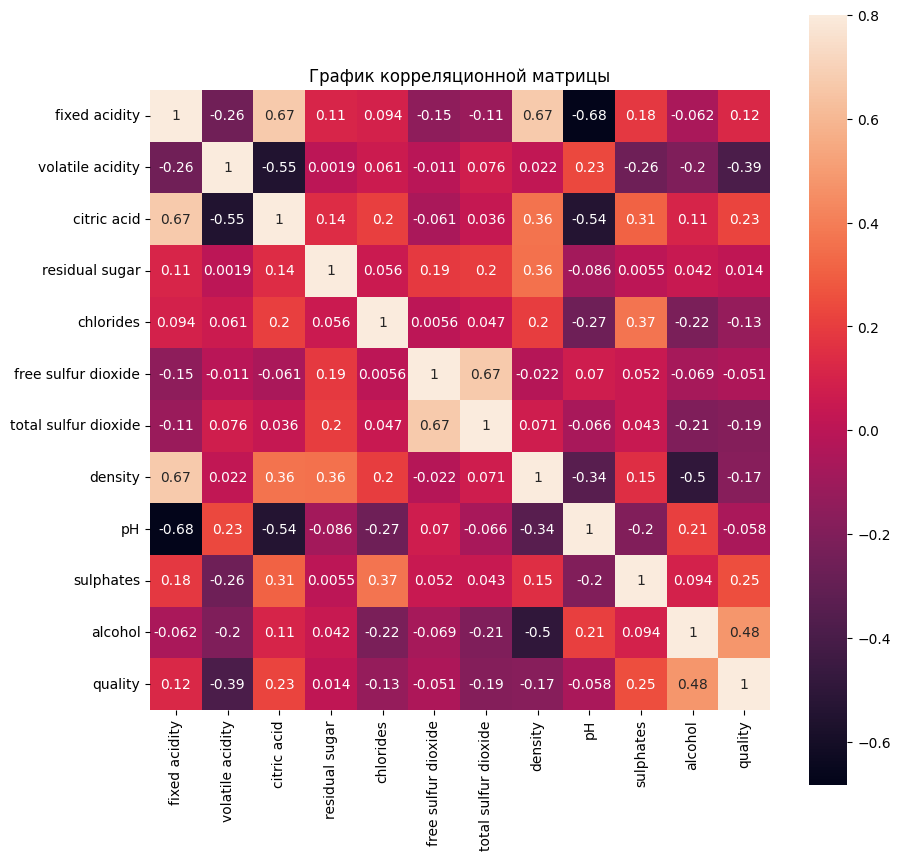

In [15]:
#график корреляционной матрицы
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, vmax = .8, square = True)
plt.title('График корреляционной матрицы')
plt.show()

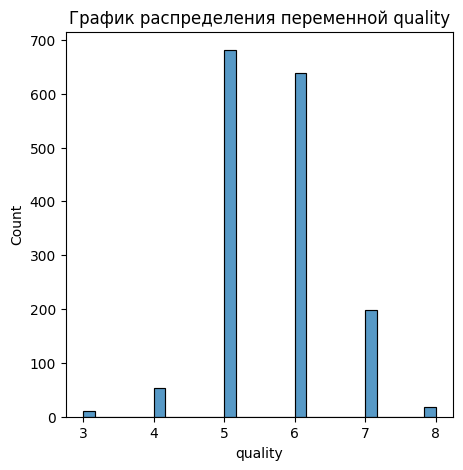

In [16]:
#график распределения переменной target
plt.figure(figsize=(5, 5))
sns.histplot(red_pd.quality)
plt.title('График распределения переменной quality')
plt.show()

In [17]:
#анализ нулевых значений, отсутствуют
red_pd_null=red_pd.isnull().sum()
red_pd_null

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [18]:
red_pd_reduse = red_pd[(red_pd.quality >= 5) & (red_pd.quality <= 6)]
red_pd_reduse.shape

(1319, 12)

In [19]:
y = red_pd_reduse.quality
X = red_pd_reduse.drop(['quality'], axis=1)

In [20]:
#независимые переменные
X.shape

(1319, 11)

In [21]:
X.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [22]:
#целевая переменная
y.shape

(1319,)

In [23]:
from sklearn.model_selection import train_test_split

#разбиваем датасет на обучающий и проверочный
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("y_train", y_train.shape)
print("y_val", y_val.shape)

X_train (1055, 11)
X_val (264, 11)
y_train (1055,)
y_val (264,)


In [24]:
from sklearn.svm import SVC

#строим модель
model_SVC = SVC(kernel='linear', C=1)
model_SVC.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [25]:
#расчет целевой переменной на тестовой выборке
y_pred = model_SVC.predict(X_val)
y_pred

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 6, 5,
       5, 6, 5, 6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 5, 6, 6, 5, 6, 5,
       6, 5, 6, 5, 5, 6, 6, 5, 5, 6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5,
       6, 6, 5, 5, 5, 6, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 5,
       5, 6, 5, 6, 6, 5, 6, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 6, 5,
       6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 5, 6, 6, 6,
       5, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 6, 6, 6, 5, 5, 5, 5, 6, 5, 6, 6,
       6, 5, 5, 6, 6, 6, 5, 5, 5, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5,
       6, 6, 6, 6, 5, 5, 5, 6, 5, 6, 6, 5, 5, 6, 5, 6, 5, 6, 5, 5, 6, 5,
       6, 5, 5, 5, 5, 5, 5, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6, 5, 6, 5,
       5, 5, 6, 6, 6, 5, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5, 5, 5, 6, 6, 5, 6,
       6, 6, 5, 5, 5, 6, 5, 5, 5, 6, 5, 5, 5, 5, 5, 5, 5, 6, 6, 5, 5, 5])

In [26]:
print(y_val.array)

<NumpyExtensionArray>
[5, 5, 6, 6, 5, 5, 5, 5, 6, 6,
 ...
 5, 6, 6, 5, 6, 6, 5, 6, 5, 6]
Length: 264, dtype: int64


In [27]:
r_sq = model_SVC.score(X_train, y_train)
print('Коэффициент детерминации', r_sq)

Коэффициент детерминации 0.7090047393364929


In [28]:
r_sq = model_SVC.score(X_val, y_val)
print('Коэффициент детерминации', r_sq)

Коэффициент детерминации 0.7386363636363636


In [29]:
#метрики для оценки модели
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
print('mean_squared_error', mse)
print('mean_absolute_error', mae)

mean_squared_error 0.26136363636363635
mean_absolute_error 0.26136363636363635


In [30]:
#параметры модели
slope = model_SVC.coef_
print('slope:', slope)

slope: [[ 0.11209486 -2.14642237 -0.9998328   0.01310878 -0.66615749  0.01868363
  -0.01404098  0.0076161   0.04724619  1.55835111  0.82903379]]


In [31]:
#параметры модели
intercept = model_SVC.intercept_
print('intercept:', intercept)

intercept: [-8.8975641]


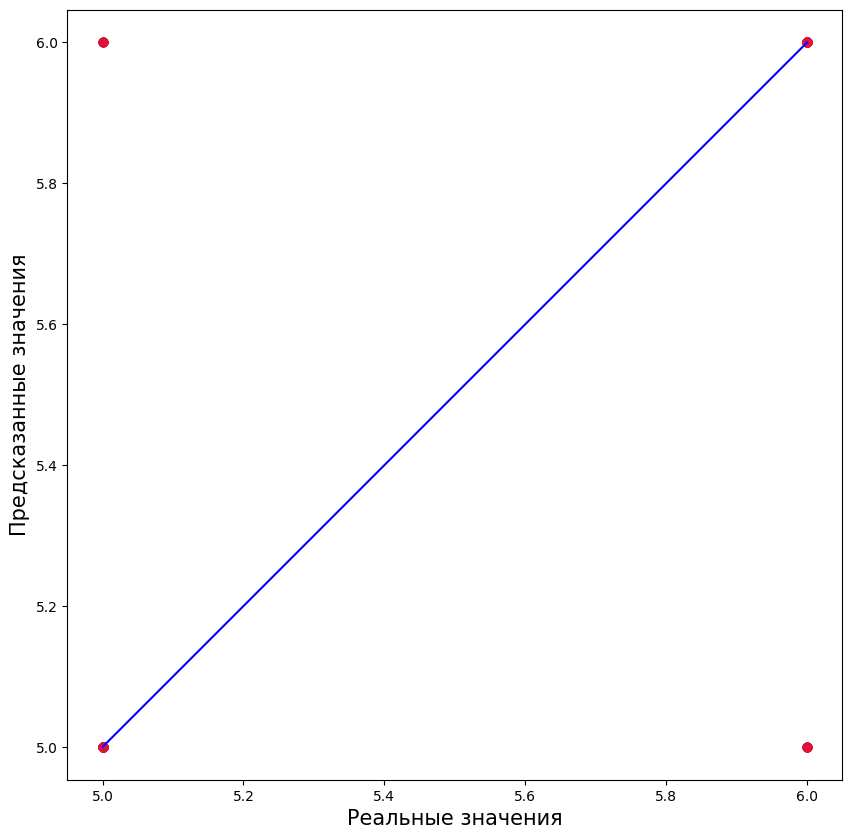

In [64]:
plt.figure(figsize=(10,10))
plt.scatter(y_val, y_pred, c='crimson')
p1 = max(max(y_pred), max(y_val))
p2 = min(min(y_pred), min(y_val))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Реальные значения', fontsize=15)
plt.ylabel('Предсказанные значения', fontsize=15)
plt.axis('equal')
plt.show()

In [65]:
from sklearn.metrics import recall_score
print(recall_score(y_val, y_pred, average=None))

[0.79285714 0.67741935]


In [37]:
def mse_manual(A, B, w, w0):

    n_samples = len(A)
    error = 0.0
    for i in range(n_samples):
        x = A[i]
        y = B[i]
        prediction = sum(w[j] * x[j] for j in range(len(x))) + w0
        error += (prediction - y) ** 2
    return error / n_samples

In [63]:
def svm_manual(A, B, learning_rate=0.001, iterations=1000, C=1.0):
#A: независимые переменные
#B: целевая переменная
#learning_rate: коэффициент обучения
#iterations: число итераций
#C: параметр регуляризации

    n_samples = len(A)
    n_features = len(A[0])

    #стартовые значения
    w = [0.0] * n_features
    w0 = 0.0

    k = 0

    for _ in range(iterations):
        gw = [0.0] * n_features
        gw0 = 0.0

        for i in range(n_samples):
            x = A[i]
            y = B[i]
            #предсказание для y: w · x + w0
            y_pred = sum(w[j] * x[j] for j in range(n_features)) + w0

            #если точка неправильно определена или лежит внутри зазора
            if y * y_pred < 1:
                for j in range(n_features):
                    gw[j] = gw[j] + w[j] - C * y * x[j]
                gw0 = gw0 - C * y
            #иначе
            else:
                for j in range(n_features):
                    gw[j] = gw[j] + w[j]

        gw = [g / n_samples for g in gw]
        gw0 = gw0 / n_samples

        #обновленные значения
        w = [w[j] - learning_rate * gw[j] for j in range(n_features)]
        w0 = w0 - learning_rate * gw0

        k += 1
        #ыычисляем mse на обучающих данных
        mse_man = mse_manual(A, B, w, w0)
        print("iteration", k, "=", mse_man)

    return w, w0

In [33]:
X_train_np = X_train.values.tolist()
X_val_np = X_val.values.tolist()

y_train_np = y_train.values.tolist()
y_val_np = y_val.values.tolist()

y_train_np = [b[0] if isinstance(b, list) else b for b in y_train_np]
y_val_np = [b[0] if isinstance(b, list) else b for b in y_val_np]

In [61]:
w, w0 = svm_manual(X_train_np, y_train_np, learning_rate = 0.001, iterations = 1000, C = 1.0)
print("Найденные параметры модели:")
print("w =", w)
print("w0 =", w0)

iteration 1 = 178.7670153316823
iteration 2 = 178.3063973548607
iteration 3 = 177.84686398389522
iteration 4 = 177.38841288682772
iteration 5 = 176.93104173652605
iteration 6 = 176.47474821067365
iteration 7 = 176.01952999176012
iteration 8 = 175.56538476707036
iteration 9 = 175.11231022867545
iteration 10 = 174.6603040734244
iteration 11 = 174.20936400293195
iteration 12 = 173.75948772356978
iteration 13 = 173.3106729464579
iteration 14 = 172.86291738745345
iteration 15 = 172.4162187671423
iteration 16 = 171.97057481082805
iteration 17 = 171.52598324852545
iteration 18 = 171.08244181494507
iteration 19 = 170.63994824949108
iteration 20 = 170.19850029624527
iteration 21 = 169.75809570396174
iteration 22 = 169.31873222605546
iteration 23 = 168.8804076205932
iteration 24 = 168.4431196502832
iteration 25 = 168.00686608246937
iteration 26 = 167.57164468911563
iteration 27 = 167.13745324680264
iteration 28 = 166.70428953671328
iteration 29 = 166.27215134462912
iteration 30 = 165.84103646091

In [57]:
mse_man = mse_manual(X_train_np, y_train_np, w, w0)
print('mean_squared_error', mse_man)

mean_squared_error 12.268180176371075


In [58]:
mse_man = mse_manual(X_val_np, y_val_np, w, w0)
print('mean_squared_error', mse_man)

mean_squared_error 13.266203395023396
